# **EXPLORATORY DATA ANALYSIS**

**Description:** This notebook performs an Exploratory Data Analysis (EDA) on the `[data_cleaned.csv]` dataset. The primary objective is to understand the underlying data structure, inspect missing values and outliers, analyze variable distributions, and visualize key correlations with the target variable `[track_popularity]`. The insights gained here will guide the baseline models, feature engineering, and subsequent modeling phases.


### **RELOAD DATA & LIBRARY**

In [2]:
#Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.linear_model as lm
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Show all columns, without hiding any
pd.set_option('display.max_columns', None)

#Set the chart background to white with a grid for easier observation and comparison of data values.
sns.set(style="whitegrid")

In [4]:
#Load the dataset
path = "../Data/data_cleaned.csv"
df = pd.read_csv(path)

#Quick look at the data
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year,release_month
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025,10
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,2025,10
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,Unknown,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,2025,10
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025,10
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,2025,10


### **EXPLORATORY DATA ANALYSIS**

This section performs an in-depth exploration of the dataset using statistical summaries and visualizations to better understand the characteristics of the data. The analysis helps identify distributions, trends, correlations, outliers, and relationships between variables, providing important insights for feature selection, data preprocessing, and machine learning model development.

In [24]:
df_cleaned = df.copy()

 **1. Target Analysis (Track Popularity)**

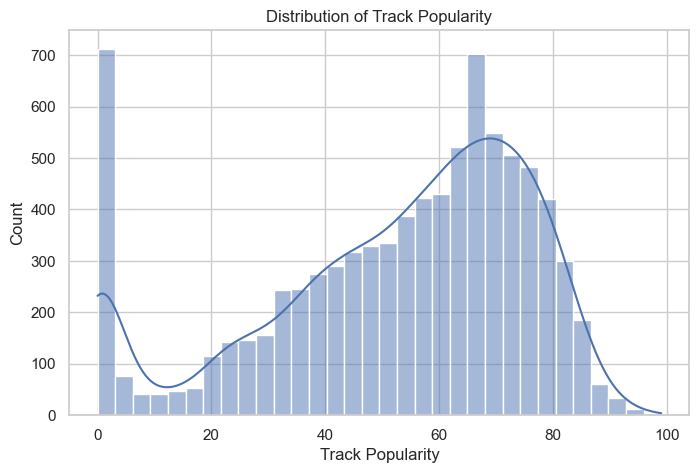

In [5]:
import matplotlib.pyplot as plt
# Histogram popularity
plt.figure(figsize=(8,5))
sns.histplot(df['track_popularity'], kde=True)
plt.title("Distribution of Track Popularity")
plt.xlabel("Track Popularity")
plt.show()

The distribution of `track_popularity` shows that most tracks are concentrated in the medium popularity range, while only a small proportion reach very high popularity scores. This indicates that becoming a highly popular or Hit track ( >80) is relatively rare in the dataset.

This insight is important for modeling because the target class is likely to be imbalanced. If most tracks are not extremely popular, a model may easily achieve high accuracy by predicting the majority class, but fail to detect actual Hit songs.

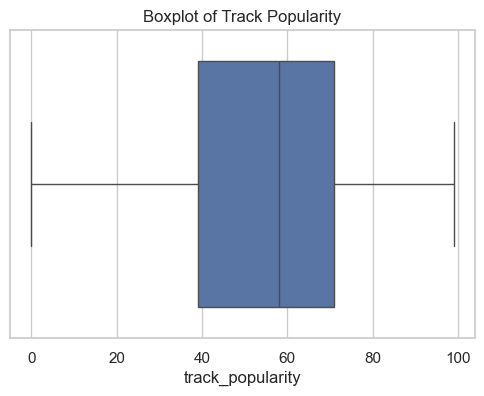

In [6]:
# Boxplot popularity
plt.figure(figsize=(6,4))
sns.boxplot(x=df['track_popularity'])
plt.title("Boxplot of Track Popularity")
plt.show()

The boxplot shows that track_popularity has a wide range, but most values are still within a reasonable Spotify popularity scale. The median popularity score is around 60, indicating that most songs in the dataset have moderate popularity levels. 

There are no clearly invalid popularity values after cleaning, which suggests that the target-related variable is suitable for further analysis.

The median popularity is around the middle-to-high range, but tracks above the Hit threshold are still much fewer than normal tracks. This supports the decision to define is_hit carefully and treat this as an imbalanced classification problem.

 **2. Numerical Features Analysis**

In [7]:
# NUMERICAL FEATURES ANALYSIS

numerical_cols = [
    'track_number',
    'artist_popularity',
    'artist_followers',
    'album_total_tracks',
    'track_duration_min'
]

*2.1. Distribution*

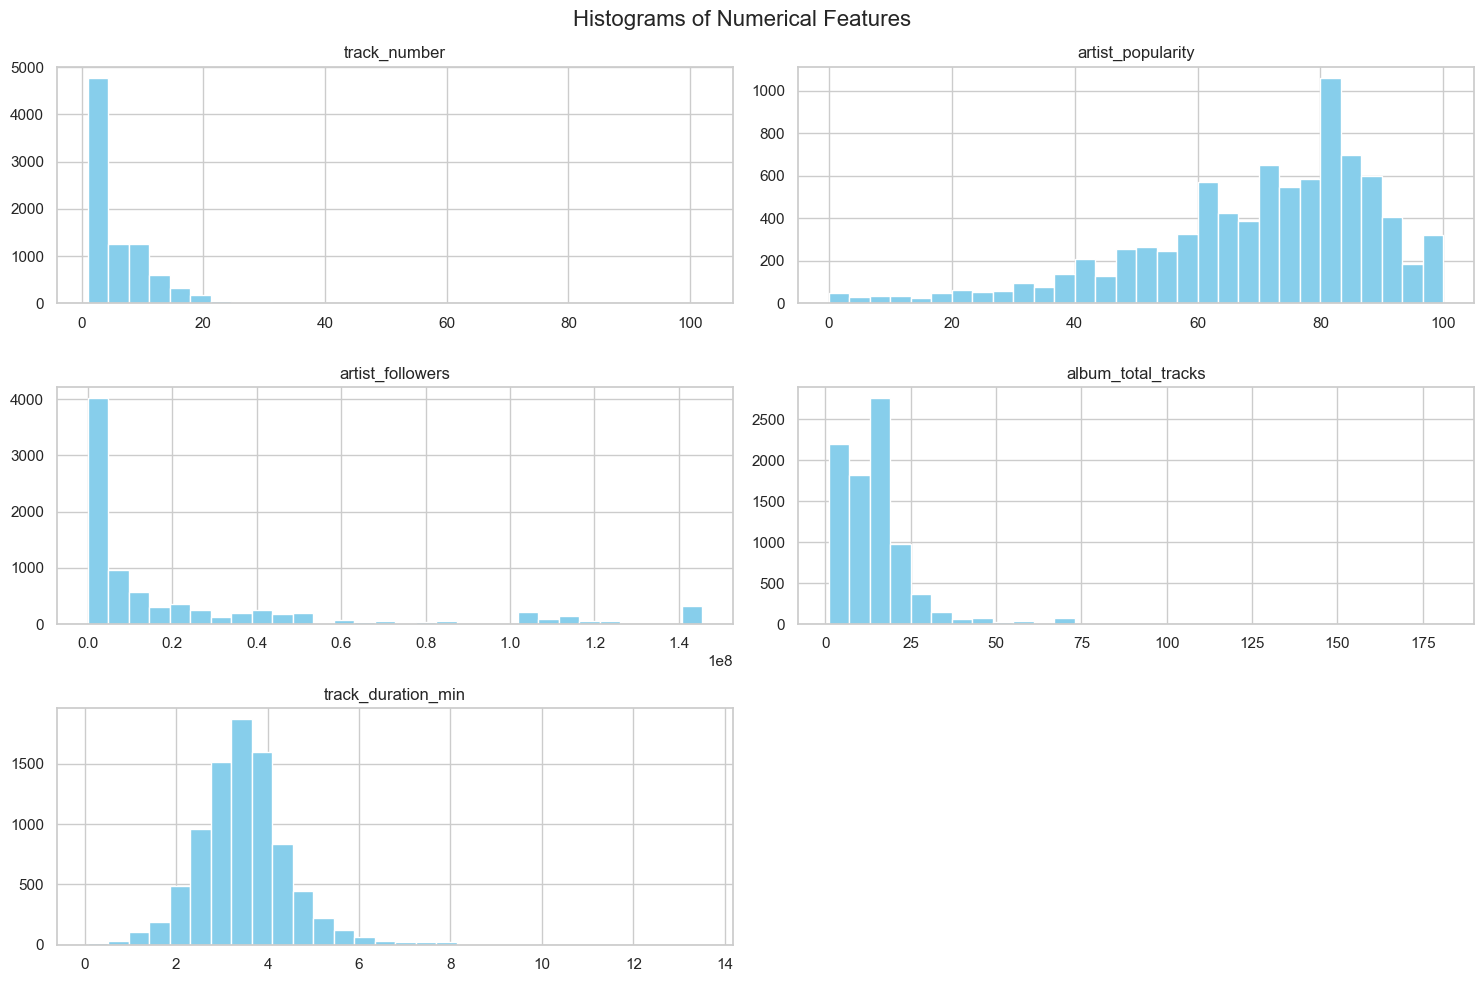

In [8]:
# Histograms

df[numerical_cols].hist(
    figsize=(15,10),
    bins=30,
    color='skyblue'
)

plt.suptitle(
    "Histograms of Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

The numerical feature overview shows that several variables are not normally distributed. In particular, features such as `artist_followers`, `album_total_tracks`, and `track_number` are right-skewed, meaning most tracks have relatively small values, while only a few records have extremely large values.

This is an important modeling insight because highly skewed features can make some values dominate the learning process. For example, superstar artists may have extremely high follower counts compared with normal artists. Therefore, feature transformation such as `artist_followers_log` is useful to reduce skewness and make the feature more stable for modeling.

*2.2. Outlier Analysis*

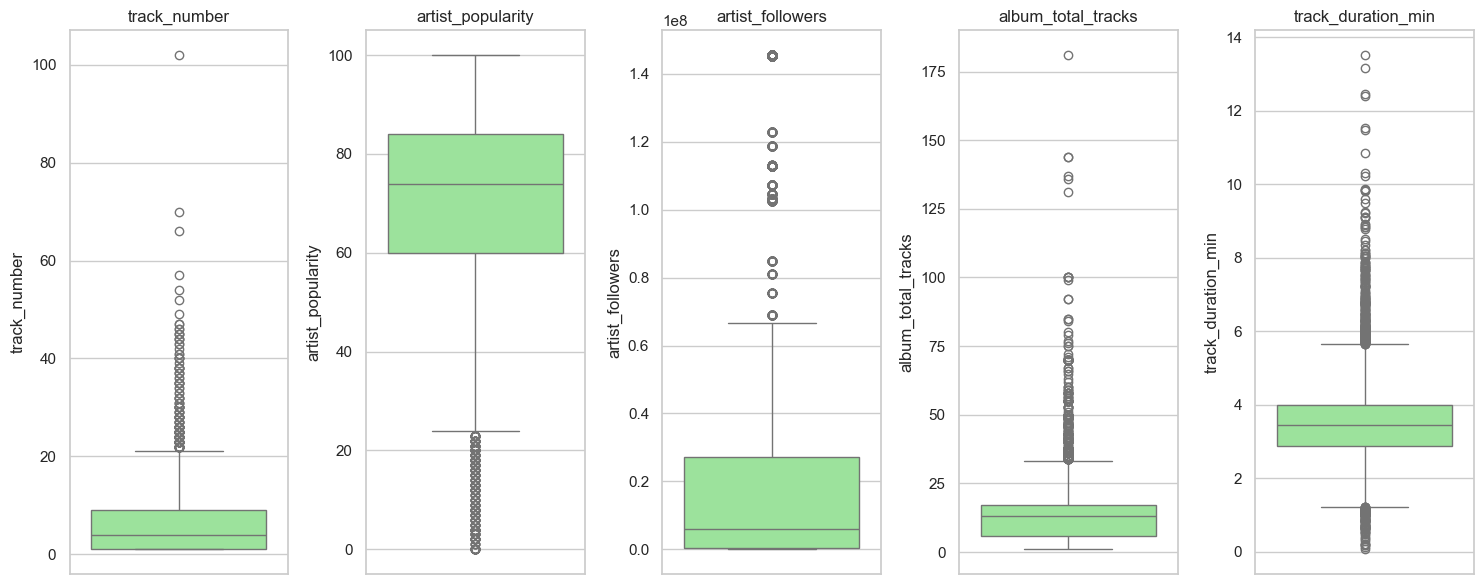

In [9]:
# Boxplots

plt.figure(figsize=(15,6))

for i, col in enumerate(numerical_cols):

    plt.subplot(1, len(numerical_cols), i+1)

    sns.boxplot(
        y=df[col],
        color='lightgreen'
    )

    plt.title(col)

plt.tight_layout()

plt.show()

The boxplots show that some numerical variables contain extreme values, especially `artist_followers` and `album_total_tracks`. However, these values are not necessarily data errors. For example, an artist with millions of followers can be a real observation, not an invalid outlier.

Therefore, the project does not remove all outliers mechanically using IQR or z-score. Instead, only logically invalid values are removed, such as negative followers, invalid duration, popularity outside 0–100, or track number greater than total album tracks. This helps preserve meaningful real-world variation while still keeping the dataset clean.

 **3. Feature Relationship Analysis**

*3.1. Correlation Heatmap*

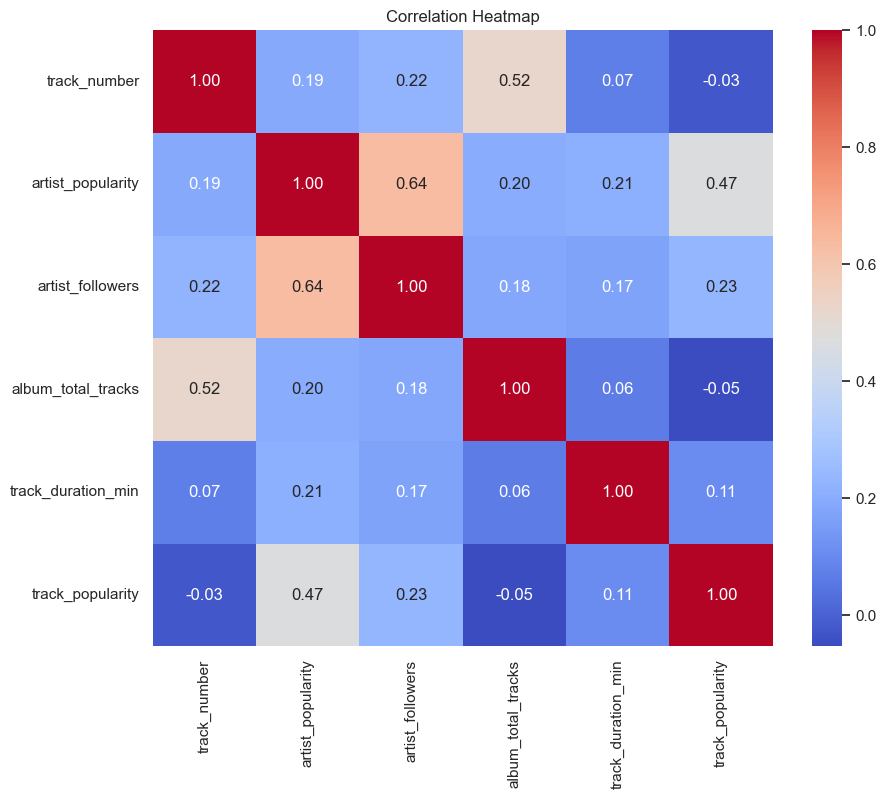

In [10]:
# CORRELATION HEATMAP

corr_cols = numerical_cols + ['track_popularity']

corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


The correlation heatmap shows that `artist_popularity` has the strongest positive relationship with `track_popularity` among the numerical features (0.47). This suggests that the popularity of the artist is an important signal for predicting whether a track can become popular.

Other technical features, such as track duration or album total tracks, show weaker correlations with popularity. This implies that song success is not mainly explained by technical track characteristics alone, but is strongly influenced by artist-level factors such as popularity and audience reach.

*3.2. Artist Popularity vs Track Popularity*

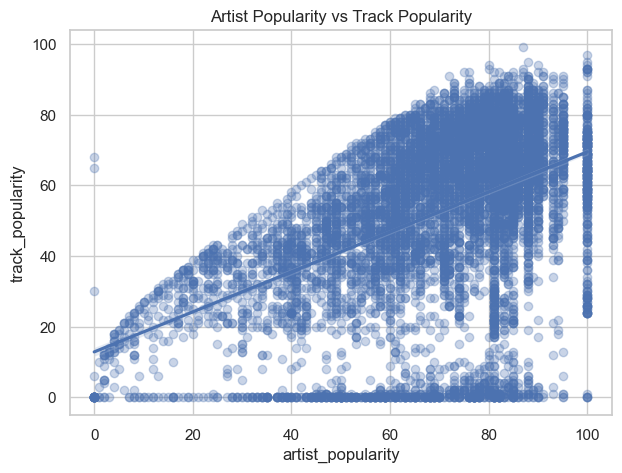

In [11]:
# Artist Popularity vs Track Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='artist_popularity',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Artist Popularity vs Track Popularity")
plt.show()

The scatter plot between `artist_popularity` and `track_popularity` shows a clear positive trend: tracks by more popular artists tend to have higher popularity scores. However, the points are still widely spread, meaning artist popularity increases the chance of success but does not guarantee that every song will become a Hit.

This insight is useful for feature engineering and model interpretation. It supports the creation of artist-related features such as `artist_is_popular`, `artist_power_score`, and `artist_pop_x_followers`. These features help the model capture the business logic that artists with stronger public recognition and fanbase are more likely to produce popular tracks.

*3.3. Artist Followers vs Track Popularity*

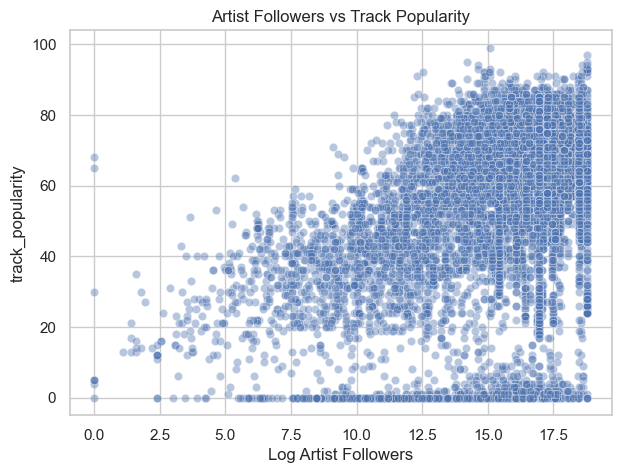

In [12]:
# Artist Followers vs Track Popularity
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=np.log1p(df['artist_followers']),
    y=df['track_popularity'],
    alpha=0.4
)
plt.title("Artist Followers vs Track Popularity")
plt.xlabel("Log Artist Followers")
plt.show()

Following the log-transformation, `artist_followers` shows a positive correlation with `track_popularity`, indicating that artists with larger fanbases generally produce more popular tracks. This log transformation is essential because raw follower counts are heavily right-skewed; without it, a few superstar artists would dominate the distribution and bias the model. However, the substantial variance in the high-follower range suggests that follower count is a necessary but not sufficient condition for success, indicating that this feature should be coupled with other variables during modeling.

*3.4. Duration vs Popularity*

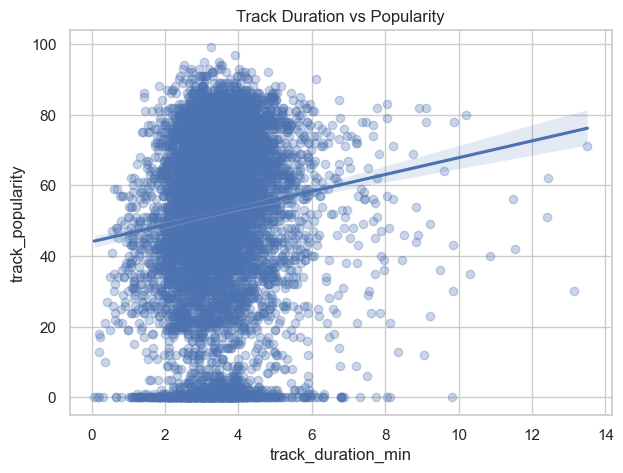

In [13]:
# Duration vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='track_duration_min',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Track Duration vs Popularity")
plt.show()

The plot shows that `track_duration_min` does not have a very strong linear relationship with `track_popularity`. Most tracks are concentrated within a common duration range, while both short and long tracks can have different popularity levels.

This suggests that duration alone is not enough to determine whether a track becomes popular. However, duration may still provide useful information when combined with other features, so the project keeps this variable and creates duration-related features such as `duration_category` and `duration_x_artist_pop`.

*3.5. Album Total Tracks vs Popularity*

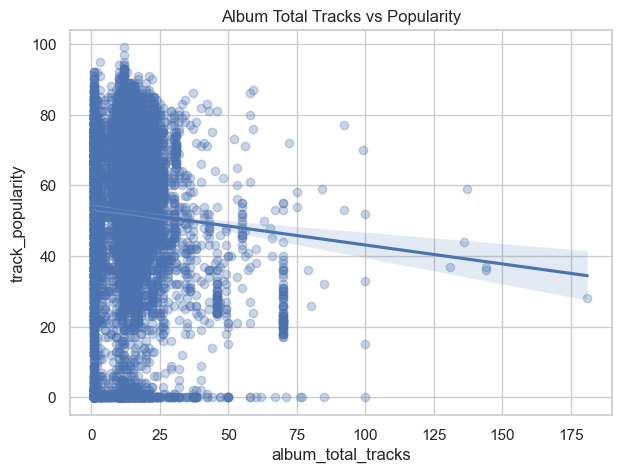

In [14]:
# Album Total Tracks vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='album_total_tracks',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Album Total Tracks vs Popularity")
plt.show()

The plot between `album_total_tracks` and `track_popularity` shows that tracks from albums with different numbers of songs can still reach various popularity levels. There is no very strong direct relationship, but album structure may still provide useful context.

This insight suggests that the number of tracks in an album may not directly determine popularity, but it can reflect release format and promotion strategy. For example, singles or shorter projects may receive more focused promotion, while tracks in longer albums may face more internal competition for listener attention.

*3.6. Track Number vs Popularity*

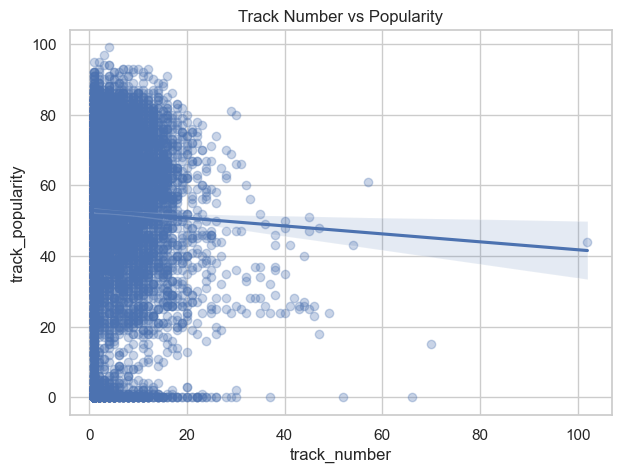

In [15]:
# Track Number vs Popularity
plt.figure(figsize=(7,5))
sns.regplot(
    x='track_number',
    y='track_popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.title("Track Number vs Popularity")
plt.show()

The relationship between `track_number` and `track_popularity` appears weak, meaning the position of a track in an album does not directly determine its popularity. However, some early tracks may still receive more attention because listeners often start from the beginning of an album.

This insight supports the creation of `track_position_ratio`, which provides a more meaningful measure than raw track number. Instead of only knowing the track number, the ratio shows where the song is located relative to the full album.

*3.7. Explicit vs Popularity*

C:\Users\Admin\AppData\Local\Temp\ipykernel_3736\2052588165.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


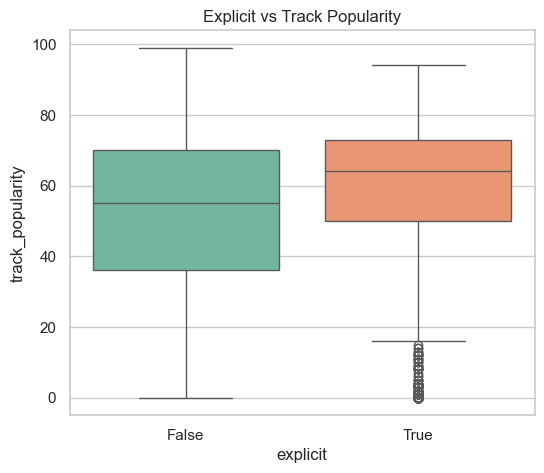

In [16]:
# Explicit vs Popularity

plt.figure(figsize=(6,5))

sns.boxplot(
    x='explicit',
    y='track_popularity',
    data=df,
    palette='Set2'
)

plt.title("Explicit vs Track Popularity")

plt.show()

The boxplot compares popularity between explicit and non-explicit tracks. If the median popularity differs between the two groups, it suggests that explicit content may be related to different audience segments or music genres.

However, explicit status alone should not be interpreted as a direct cause of popularity. It is more useful when combined with other factors such as genre and artist popularity. Therefore, the project keeps `explicit` as a categorical feature and also creates interaction features such as `explicit_x_artist_pop`.

*3.8. Album Type Distribution*

C:\Users\Admin\AppData\Local\Temp\ipykernel_3736\548883901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


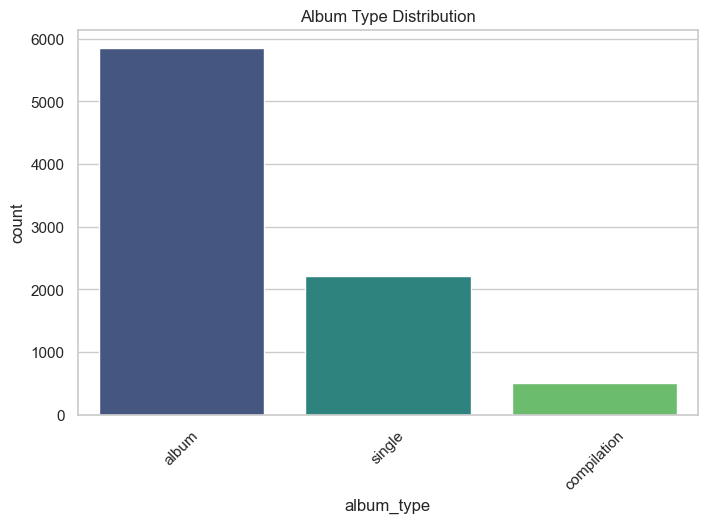

In [17]:
# Album Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='album_type',
    data=df,
    order=df['album_type'].value_counts().index,
    palette='viridis'
)

plt.title("Album Type Distribution")

plt.xticks(rotation=45)

plt.show()


`Album` releases dominate the dataset with nearly 5,900 tracks, compared with only around 2,200 singles and fewer than 500 compilations. This suggests that the dataset—and potentially Spotify listening behavior—is strongly centered around full album releases, meaning the model may learn hit patterns more effectively from album-based promotion and artist branding than from compilation releases.


*3.9. Album Type vs Popularity*

C:\Users\Admin\AppData\Local\Temp\ipykernel_3736\563399129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


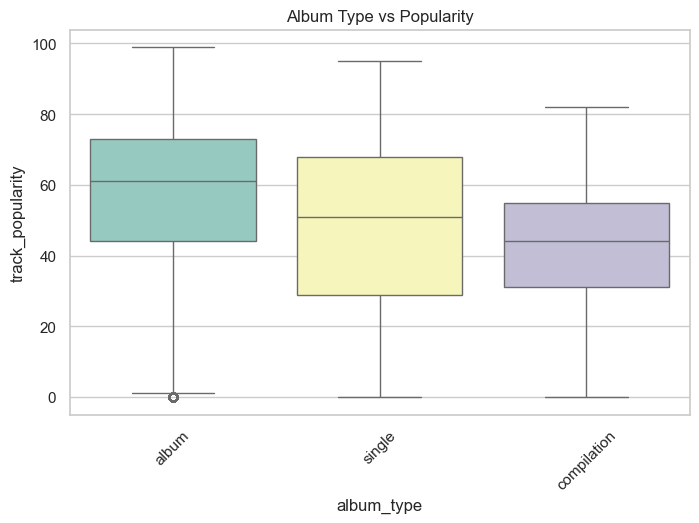

In [18]:
# Album Type vs Popularity

plt.figure(figsize=(8,5))

sns.boxplot(
    x='album_type',
    y='track_popularity',
    data=df,
    palette='Set3'
)

plt.title("Album Type vs Popularity")

plt.xticks(rotation=45)

plt.show()

Tracks released as full `albums` show the highest median popularity (around 60), outperforming both `singles` (about 50) and `compilations` (about 44). This suggests that artist reputation and large-scale album promotion may contribute more to streaming success than releasing standalone singles, while compilation tracks appear to receive weaker audience attention and marketing focus.

*3.10. Extract all genres*

In [19]:
# Clean genres
df['artist_genres'] = df['artist_genres'].fillna('Unknown')


C:\Users\Admin\AppData\Local\Temp\ipykernel_3736\1829810895.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


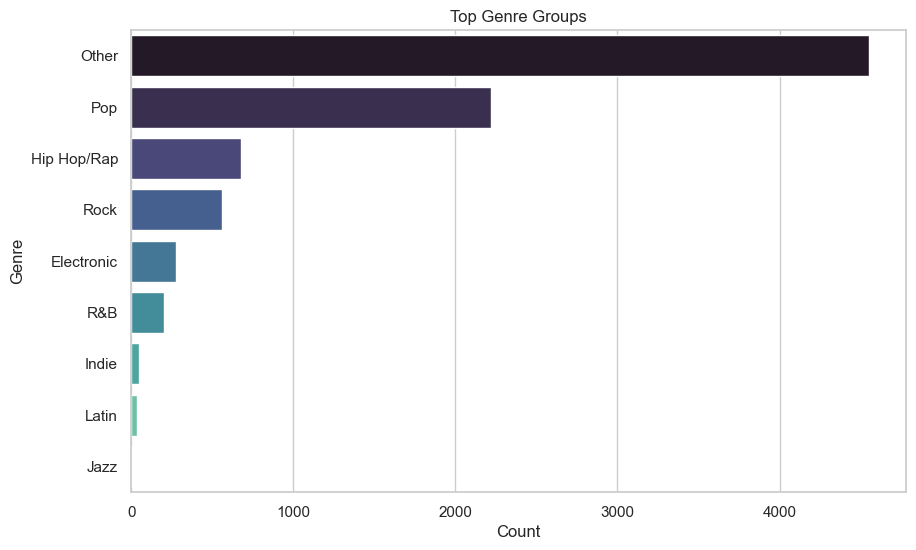

In [20]:
# Extract all genres

genre_list = []

for genres in df['artist_genres']:

    split_genres = str(genres).split(',')

    split_genres = [
        g.strip().lower()
        for g in split_genres
    ]

    genre_list.extend(split_genres)

# Group similar genres

def simplify_genre(genre):

    if 'pop' in genre:
        return 'Pop'

    elif 'rock' in genre:
        return 'Rock'

    elif 'rap' in genre or 'hip hop' in genre or 'trap' in genre:
        return 'Hip Hop/Rap'

    elif 'electronic' in genre or 'edm' in genre or 'house' in genre:
        return 'Electronic'

    elif 'indie' in genre:
        return 'Indie'

    elif 'r&b' in genre or 'soul' in genre:
        return 'R&B'

    elif 'latin' in genre:
        return 'Latin'

    elif 'jazz' in genre:
        return 'Jazz'

    else:
        return 'Other'

# Create genre_group column

df['genre_group'] = df['artist_genres'].apply(
    lambda x: simplify_genre(str(x))
)

# Top Genre Groups

top_genres = df['genre_group'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='mako'
)

plt.title("Top Genre Groups")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

The genre distribution is highly concentrated, with the Other group accounting for more than 4,500 tracks and Pop contributing over 2,200 tracks, while genres such as Jazz, Latin, and Indie each contain fewer than 100 songs. This suggests that Spotify genre labels are highly fragmented and that mainstream genres dominate the dataset, implying that genre alone may not strongly predict Hit songs compared with artist-related factors such as popularity and followers.

*3.11. Genre vs Average Popularity*

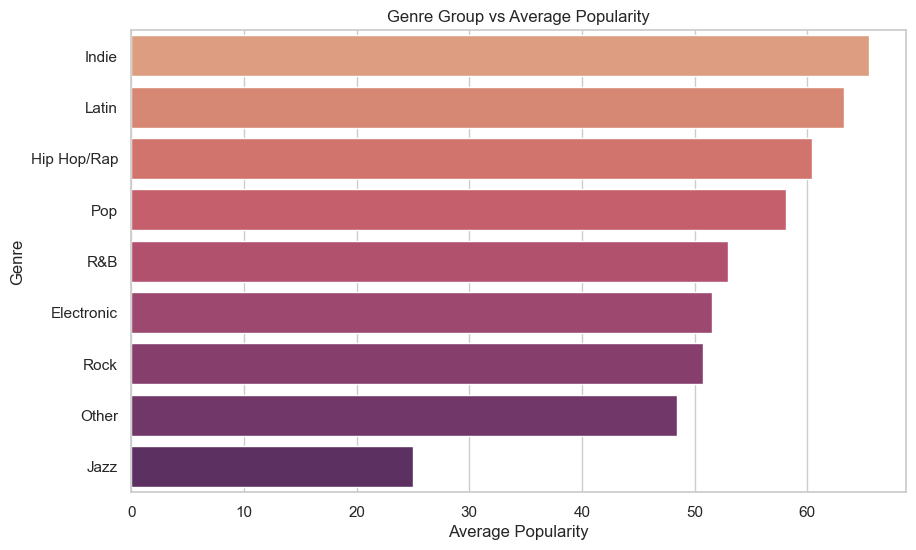

In [21]:
# Genre vs Average Popularity

genre_popularity = (
    df.groupby('genre_group')['track_popularity']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    hue=genre_popularity.index,
    legend=False,
    palette='flare'
)

plt.title("Genre Group vs Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

Indie and Latin songs have the highest average popularity, reaching around 66 and 63 respectively, while Jazz has the lowest average popularity at only about 25. This suggests that listener demand and streaming performance differ significantly across genres, making genre an important feature for predicting a song’s hit potential.


*3.12. Time Analysis*

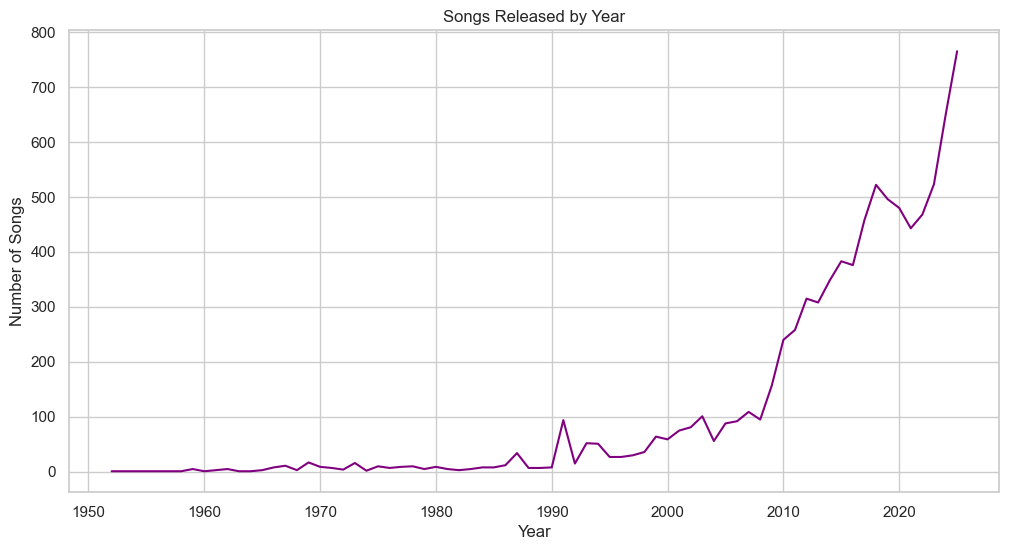

In [ ]:
# Time Analysis
df['album_release_date'] = df_cleaned['album_release_date']

df['release_year'] = df_cleaned['release_year']

# Songs Released by Year

plt.figure(figsize=(12,6))

df['release_year'].value_counts() \
    .sort_index() \
    .plot(color='purple')

plt.title("Songs Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Songs")

plt.show()

The number of songs in the dataset increased dramatically after 2010, rising from around 100 songs per year in the late 2000s to over 750 songs by 2025. This reflects the rapid expansion of digital music platforms and streaming services, which significantly lowered the barrier for music distribution and led to a much higher volume of song releases in recent years.


*3.12. Popularity by Year*

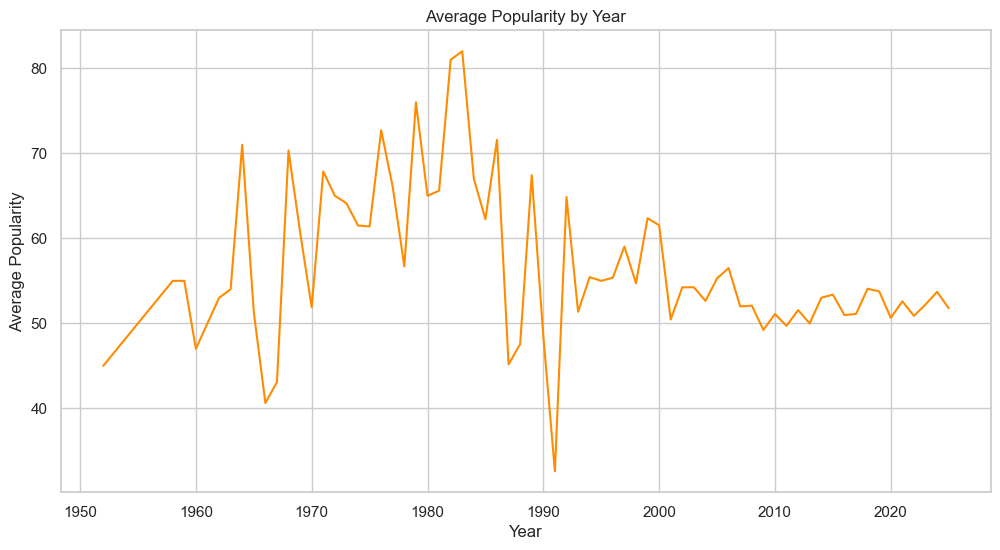

In [26]:
# Popularity by Year

year_popularity = (
    df.groupby('release_year')['track_popularity']
    .mean()
)

plt.figure(figsize=(12,6))

year_popularity.plot(color='darkorange')

plt.title("Average Popularity by Year")
plt.xlabel("Year")
plt.ylabel("Average Popularity")

plt.show()

Average track popularity fluctuated significantly before the 1990s, reaching a peak of around 82 in the early 1980s before dropping sharply to nearly 33 around 1991. After 2000, popularity became much more stable, mostly ranging between 50 and 55. This suggests that the modern music market has become more competitive and balanced, with fewer extreme popularity differences between songs compared to earlier decades.

### **CONCLUSION**

The EDA highlights several key patterns that guided the modeling process. \
**First**, the dataset is highly imbalanced, with only about 7% Hit songs, so the project focuses more on Recall and F1-score instead of accuracy. \
**Second**, artist-related features such as artist_popularity and artist_followers show the strongest relationship with Hit probability, leading to engineered features like artist_power_score and interaction variables. \
**Third**, album and genre analyses suggest that release format and mainstream genres influence popularity, motivating features such as album_type and 'genre_group. \
**Finally**, temporal patterns in release years support the use of a time-based train-validation-test split to better reflect real-world prediction scenarios.